In [16]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif


In [17]:
# Настройка библиотек 

# NumPy: удобство вывода
np.set_printoptions(
    precision=3,      # количество знаков после запятой
    suppress=True     # отключает научную нотацию
)

# Pandas: основные display-настройки
pd.set_option('display.max_rows', 100)        # сколько строк показывать
pd.set_option('display.max_columns', 50)      # сколько колонок
pd.set_option('display.width', 120)            # ширина вывода
pd.set_option('display.float_format', '{:.2f}'.format)

# Matplotlib: базовый стиль
plt.style.use('default')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False

sns.set_theme(
    style="whitegrid",
    context="notebook"
)
sns.set_context("talk")

warnings.filterwarnings("ignore")


<h2>Работа с данными</h2>

In [18]:
df = pd.read_csv('data/dataset_phishing.csv')
print(f'Размерность: {df.shape}')
df.head()

Размерность: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,...,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,...,0,0.50,0,0,80.00,0,100.00,0.00,0,0,0,0.00,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,...,0,0.00,0,0,100.00,0,80.00,20.00,0,0,0,100.00,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,...,0,0.00,0,0,100.00,0,0.00,0.00,0,0,0,100.00,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,...,0,0.25,0,0,100.00,0,96.43,3.57,0,0,0,62.50,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,...,0,0.02,1,0,76.47,0,0.00,100.00,0,0,0,0.00,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


In [19]:
print('Кол-во пропусков в столбцах')
df.isna().sum()

Кол-во пропусков в столбцах


url                           0
length_url                    0
length_hostname               0
ip                            0
nb_dots                       0
nb_hyphens                    0
nb_at                         0
nb_qm                         0
nb_and                        0
nb_or                         0
nb_eq                         0
nb_underscore                 0
nb_tilde                      0
nb_percent                    0
nb_slash                      0
nb_star                       0
nb_colon                      0
nb_comma                      0
nb_semicolumn                 0
nb_dollar                     0
nb_space                      0
nb_www                        0
nb_com                        0
nb_dslash                     0
http_in_path                  0
https_token                   0
ratio_digits_url              0
ratio_digits_host             0
punycode                      0
port                          0
tld_in_path                   0
tld_in_s

In [20]:
print(f'Кол-во дубликатов: {df.duplicated().sum()}')

Кол-во дубликатов: 0


In [21]:
print(f'Типы данных: {df.dtypes}')

Типы данных: url                            object
length_url                      int64
length_hostname                 int64
ip                              int64
nb_dots                         int64
nb_hyphens                      int64
nb_at                           int64
nb_qm                           int64
nb_and                          int64
nb_or                           int64
nb_eq                           int64
nb_underscore                   int64
nb_tilde                        int64
nb_percent                      int64
nb_slash                        int64
nb_star                         int64
nb_colon                        int64
nb_comma                        int64
nb_semicolumn                   int64
nb_dollar                       int64
nb_space                        int64
nb_www                          int64
nb_com                          int64
nb_dslash                       int64
http_in_path                    int64
https_token                     int64

In [22]:
print('Распределение классов')
df['status'].value_counts()

Распределение классов


status
legitimate    5715
phishing      5715
Name: count, dtype: int64

In [23]:
def encoder_status(col_value):
    if col_value == 'legitimate':
        return 0
    elif col_value == 'phishing':
        return 1
        
df['class_status'] = df['status'].apply(encoder_status)
df = df.drop('url', axis=1)

<h2>EDA</h2>

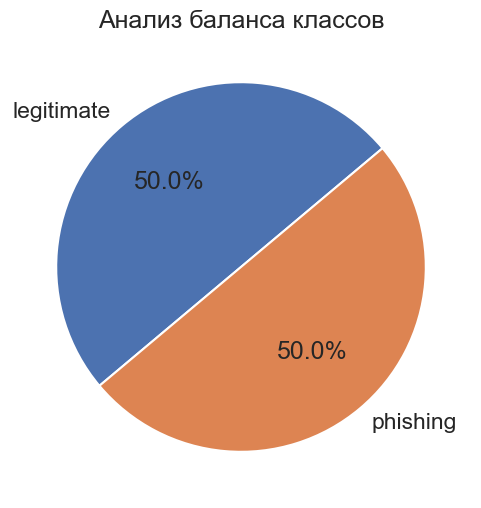

In [24]:
group_status = df['status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(labels=group_status.index, x=group_status.values, autopct='%1.1f%%', startangle=40)
plt.title('Анализ баланса классов')
plt.savefig('results/analysis/graphic/class_balance_analysis.png')
plt.show()

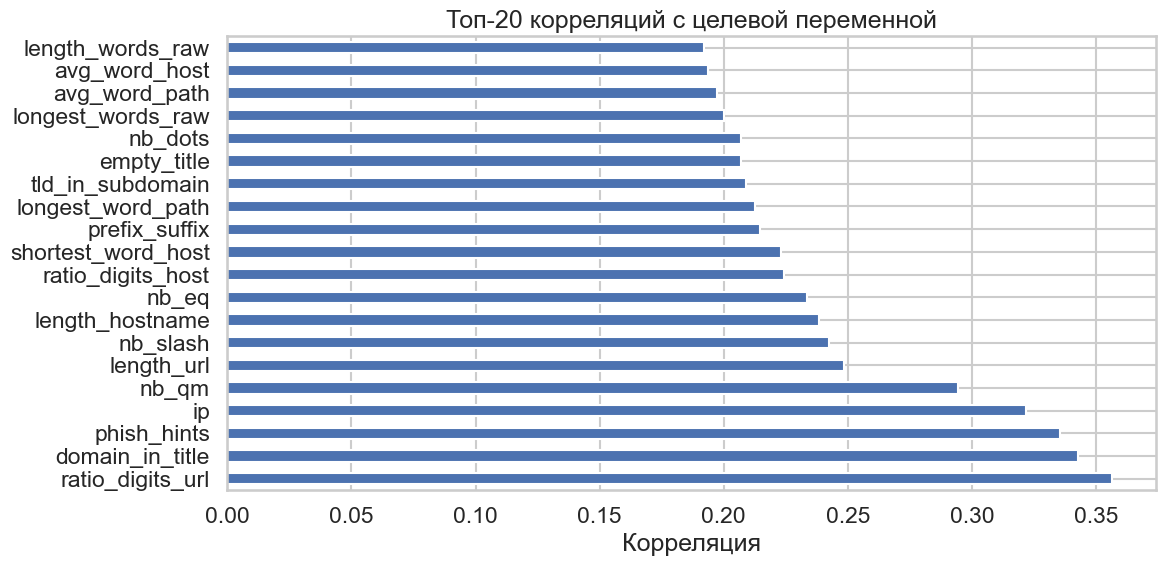

In [25]:
df_copy = df.copy()
corr_matrix = df_copy.corr(numeric_only=True)
target_corr = corr_matrix['class_status'].dropna().sort_values(ascending=False)
target_corr = target_corr.drop('class_status')

target_corr[1:21].plot(kind='barh')
plt.title('Топ-20 корреляций с целевой переменной')
plt.xlabel('Корреляция')
plt.tight_layout()
plt.savefig('results/analysis/graphic/top_20_correlations.png')
plt.show()

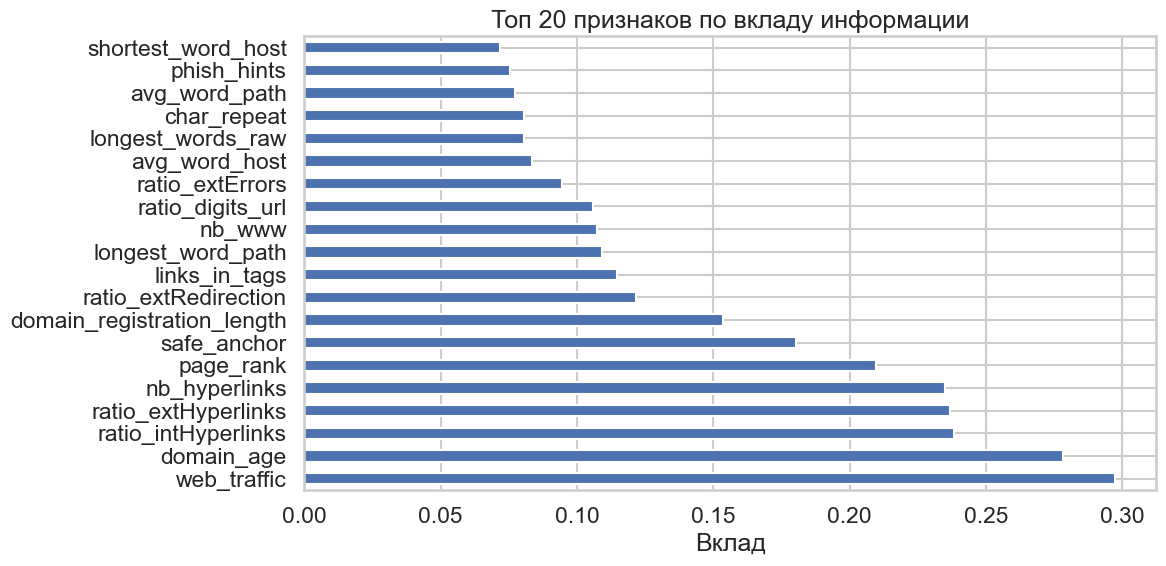

In [26]:
X = df.drop(columns=['status', 'class_status'])
y = df['class_status']

mic = mutual_info_classif(X, y)
mic_series = pd.Series(mic, index=X.columns).sort_values(ascending=False)
mask = mic_series >= 0.01
mic_series = mic_series[mask]

mic_series[1:21].plot(kind='barh')
plt.title('Топ 20 признаков по вкладу информации')
plt.xlabel('Вклад')
plt.tight_layout()
plt.savefig('results/analysis/graphic/top_20_features.png')
plt.show()

In [27]:
df_statistics = df.drop('status', axis=1)
df_statistics = df_statistics.agg(['max', 'min', 'mean', 'median', 'std']).T

df_statistics.to_excel('results/analysis/result/df_statistics.xlsx', index=False)

In [28]:
target_corr = set(target_corr.index)
mic_series = set(mic_series.index)

features_columns = list(target_corr.union(mic_series)) + ['class_status']
clean_df = df[feature_columns]

df.to_csv('results/clean_data/df_all_columns.csv', index=False)
clean_df.to_csv('results/clean_data/df_clean.csv', index=False)

In [29]:
features = set(features_columns)
all_columns = set(df.columns)

trash_columns = all_columns - features
print(f'Столбцы у которых нет корреляции или не приносят вклада для обучения: ' + ', '.join(trash_columns))


Столбцы у которых нет корреляции или не приносят вклада для обучения: ratio_intErrors, sfh, nb_or, ratio_nullHyperlinks, ratio_intRedirection, submit_email, status
